In [1]:
import pandas as pd
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

# Data Collection

In [2]:
entry_data = pd.read_csv("https://www.immd.gov.hk/opendata/eng/transport/immigration_clearance/statistics_on_daily_passenger_traffic.csv")

In [3]:
entry_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48444 entries, 0 to 48443
Data columns (total 8 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Date                 48444 non-null  object 
 1   Control Point        48444 non-null  object 
 2   Arrival / Departure  48444 non-null  object 
 3   Hong Kong Residents  48444 non-null  int64  
 4   Mainland Visitors    48444 non-null  int64  
 5   Other Visitors       48444 non-null  int64  
 6   Total                48444 non-null  int64  
 7   Unnamed: 7           0 non-null      float64
dtypes: float64(1), int64(4), object(3)
memory usage: 3.0+ MB


# Data Preprocessing & Cleaning

In [5]:
entry_data.drop(columns=["Unnamed: 7"], inplace=True)

These 3 entry points have since closed down, hence there have been no data points for these control Points

In [6]:
mask = ~entry_data["Control Point"].isin(["Hung Hom", "Sha Tau Kok", "Tuen Mun Ferry Terminal"])

entry_data = entry_data[mask]

In [7]:
entry_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 41808 entries, 0 to 48443
Data columns (total 7 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   Date                 41808 non-null  object
 1   Control Point        41808 non-null  object
 2   Arrival / Departure  41808 non-null  object
 3   Hong Kong Residents  41808 non-null  int64 
 4   Mainland Visitors    41808 non-null  int64 
 5   Other Visitors       41808 non-null  int64 
 6   Total                41808 non-null  int64 
dtypes: int64(4), object(3)
memory usage: 2.6+ MB


In [8]:
entry_data.duplicated().sum()

0

In [9]:
entry_data.isna().sum()

Date                   0
Control Point          0
Arrival / Departure    0
Hong Kong Residents    0
Mainland Visitors      0
Other Visitors         0
Total                  0
dtype: int64

In [10]:
entry_data["Date"] = pd.to_datetime(entry_data["Date"], format="%d-%m-%Y")

/var/folders/yl/rgyyql2n7zq5z298k62k1nt40000gn/T/ipykernel_48955/3600920192.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  entry_data["Date"] = pd.to_datetime(entry_data["Date"], format="%d-%m-%Y")


# Exploratory Data Analysis (EDA)

In [11]:
entry_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 41808 entries, 0 to 48443
Data columns (total 7 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   Date                 41808 non-null  datetime64[ns]
 1   Control Point        41808 non-null  object        
 2   Arrival / Departure  41808 non-null  object        
 3   Hong Kong Residents  41808 non-null  int64         
 4   Mainland Visitors    41808 non-null  int64         
 5   Other Visitors       41808 non-null  int64         
 6   Total                41808 non-null  int64         
dtypes: datetime64[ns](1), int64(4), object(2)
memory usage: 2.6+ MB


In [12]:
grouped_data = entry_data.groupby("Date", as_index=False).agg({
    "Hong Kong Residents": "sum",
    "Mainland Visitors": "sum",
    "Other Visitors": "sum",
    "Total": "sum"
})
grouped_data.head()

,Date,Hong Kong Residents,Mainland Visitors,Other Visitors,Total
0,2021-01-01,4178,290,42,4510
1,2021-01-02,4845,361,47,5253
2,2021-01-03,6462,415,99,6976
3,2021-01-04,6131,485,63,6679
4,2021-01-05,3704,222,80,4006


In [13]:
sns.set_style("whitegrid", {
    "grid.linestyle": "--",
    "grid.alpha": 0.6}) 

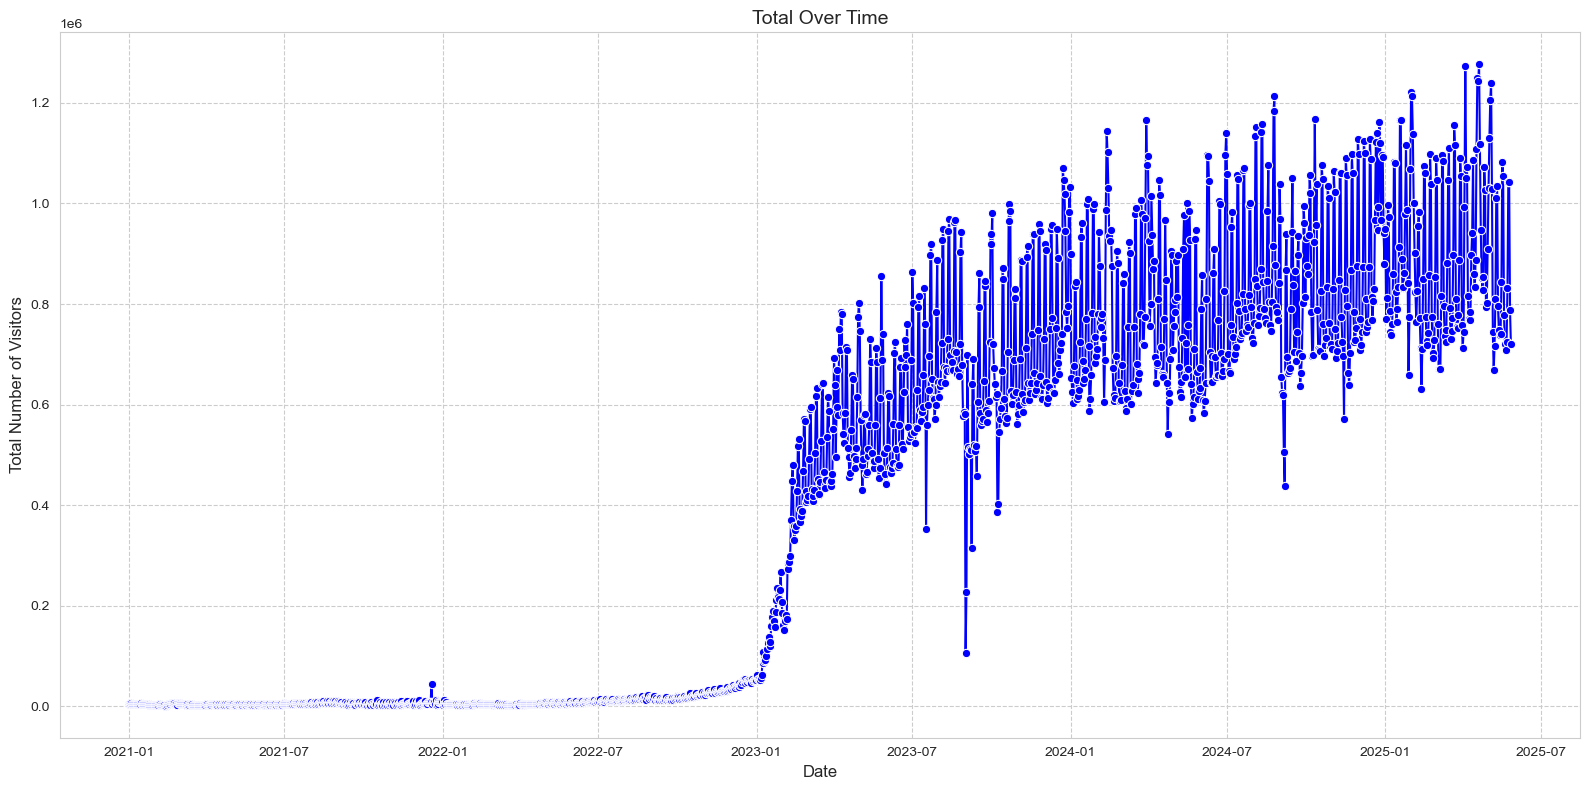

In [14]:
plt.figure(figsize=(16, 8))
sns.lineplot(data=grouped_data, x="Date", y="Total", marker="o", color="b", errorbar=None)
plt.xlabel("Date", fontsize=12)
plt.ylabel("Total Number of Visitors", fontsize=12)
plt.title("Total Over Time", fontsize=14)
plt.tight_layout()
plt.show();

In [15]:
grouped_monthly_data = grouped_data.resample("ME", on="Date")["Hong Kong Residents","Mainland Visitors", "Other Visitors", "Total"].mean().round(0).reset_index()
grouped_monthly_data.head()

,Date,Hong Kong Residents,Mainland Visitors,Other Visitors,Total
0,2021-01-31,4029.0,227.0,66.0,4322.0
1,2021-02-28,3664.0,196.0,61.0,3921.0
2,2021-03-31,3273.0,248.0,53.0,3574.0
3,2021-04-30,3255.0,230.0,61.0,3546.0
4,2021-05-31,3384.0,233.0,65.0,3682.0


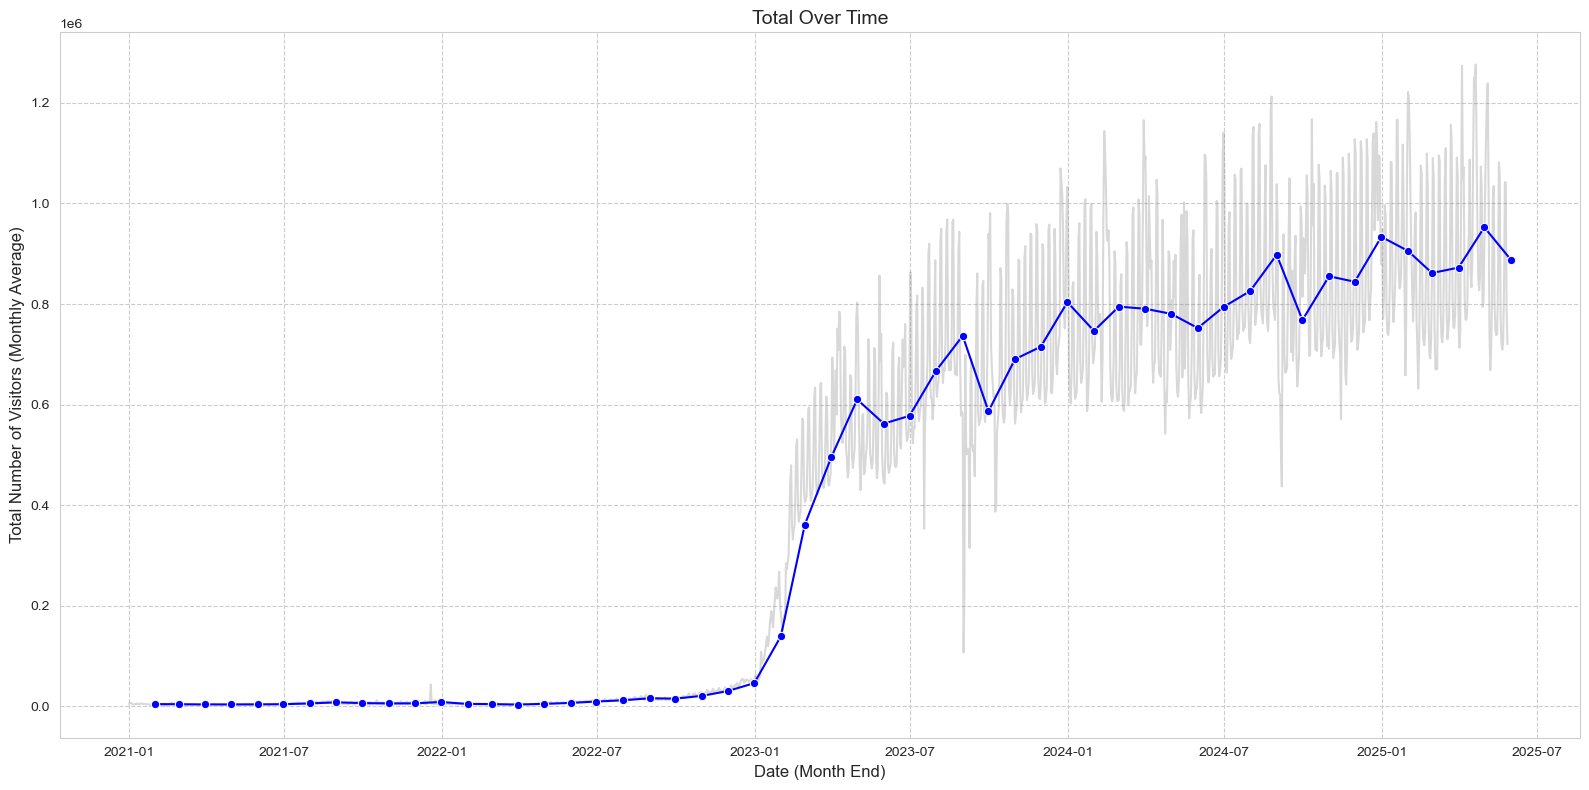

In [16]:
plt.figure(figsize=(16, 8))

sns.lineplot(data=grouped_data, x="Date", y="Total", alpha = 0.3, color="grey", errorbar=None)

sns.lineplot(data=grouped_monthly_data, x= "Date", y="Total", marker="o", color="b", errorbar=None)
plt.xlabel("Date (Month End)", fontsize=12)
plt.ylabel("Total Number of Visitors (Monthly Average)", fontsize=12)
plt.title("Total Over Time", fontsize=14)
plt.tight_layout()
plt.show();

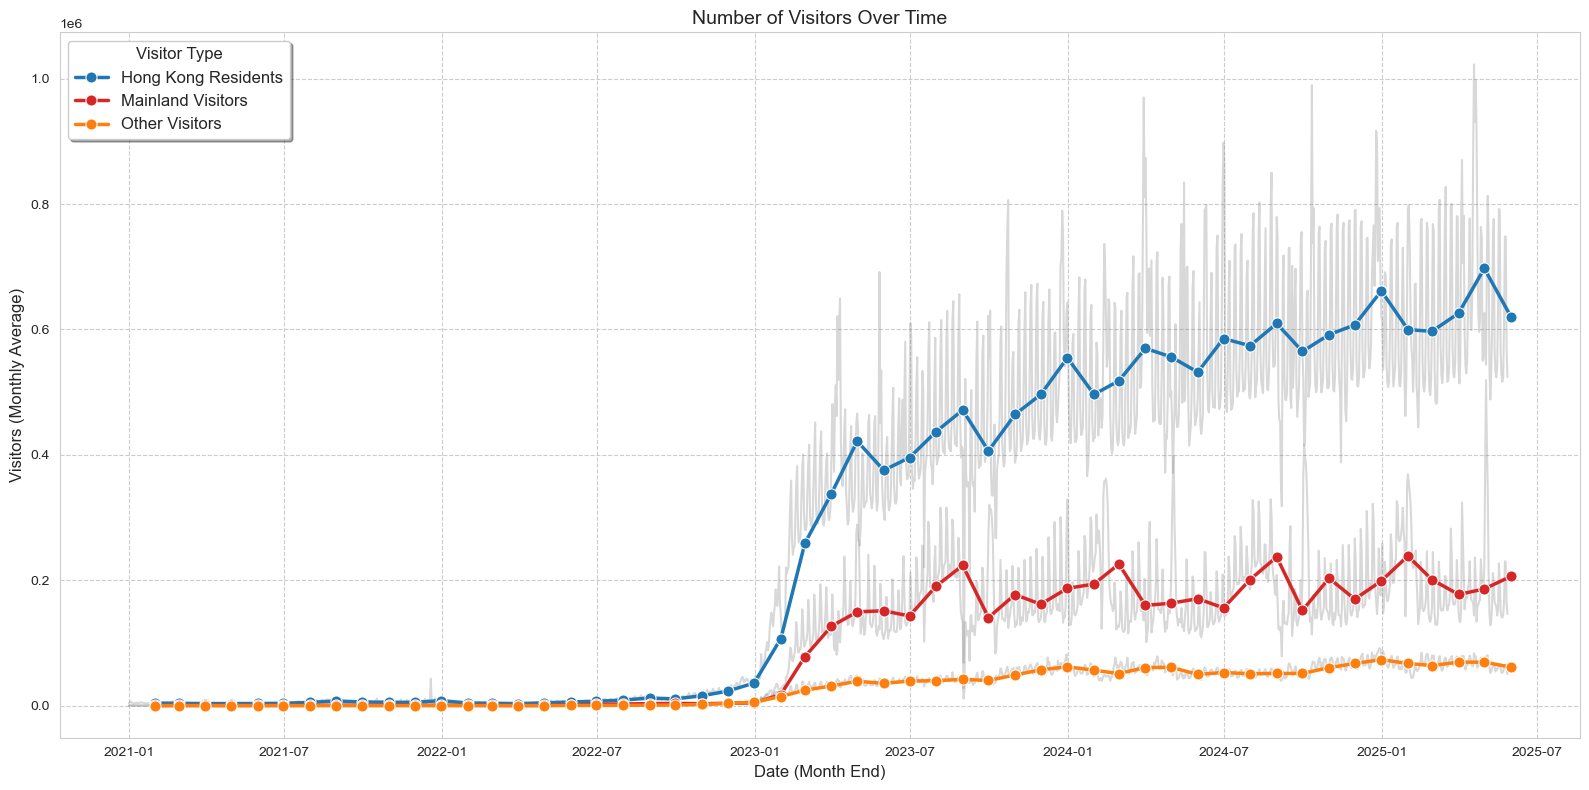

In [17]:
plt.figure(figsize=(16, 8))
color_palette = {"Hong Kong Residents": "#1f77b4",
                 "Mainland Visitors": "#d62728",    
                 "Other Visitors": "#ff7f0e"}

for column, color in color_palette.items():
    sns.lineplot(data=grouped_data, x="Date", y=column, alpha = 0.3, color="grey", errorbar=None)
    sns.lineplot(data=grouped_monthly_data, x="Date", y=column, marker="o", color=color, errorbar=None, linewidth=2.5, markersize=8, label=column)
    
plt.xlabel("Date (Month End)", fontsize=12)
plt.ylabel("Visitors (Monthly Average)", fontsize=12)
plt.title("Number of Visitors Over Time", fontsize=14)

legend = plt.legend(fontsize=12, framealpha=1, shadow=True, facecolor="white", bbox_to_anchor=(0, 1), loc="upper left")
legend.set_title("Visitor Type", prop={"size": 12})

plt.tight_layout()
plt.show();

In [18]:
monthly_data_mean = (
    entry_data.set_index("Date").groupby(["Control Point", "Arrival / Departure"]).resample("ME").agg({
        "Hong Kong Residents": "mean",
        "Mainland Visitors": "mean",
        "Other Visitors": "mean",
        "Total": "mean"
    }).round(0).reset_index())

monthly_data_mean.head()

,Control Point,Arrival / Departure,Date,Hong Kong Residents,Mainland Visitors,Other Visitors,Total
0,Airport,Arrival,2021-01-31,526.0,4.0,17.0,546.0
1,Airport,Arrival,2021-02-28,457.0,3.0,15.0,476.0
2,Airport,Arrival,2021-03-31,417.0,4.0,17.0,438.0
3,Airport,Arrival,2021-04-30,392.0,4.0,17.0,413.0
4,Airport,Arrival,2021-05-31,482.0,5.0,18.0,505.0


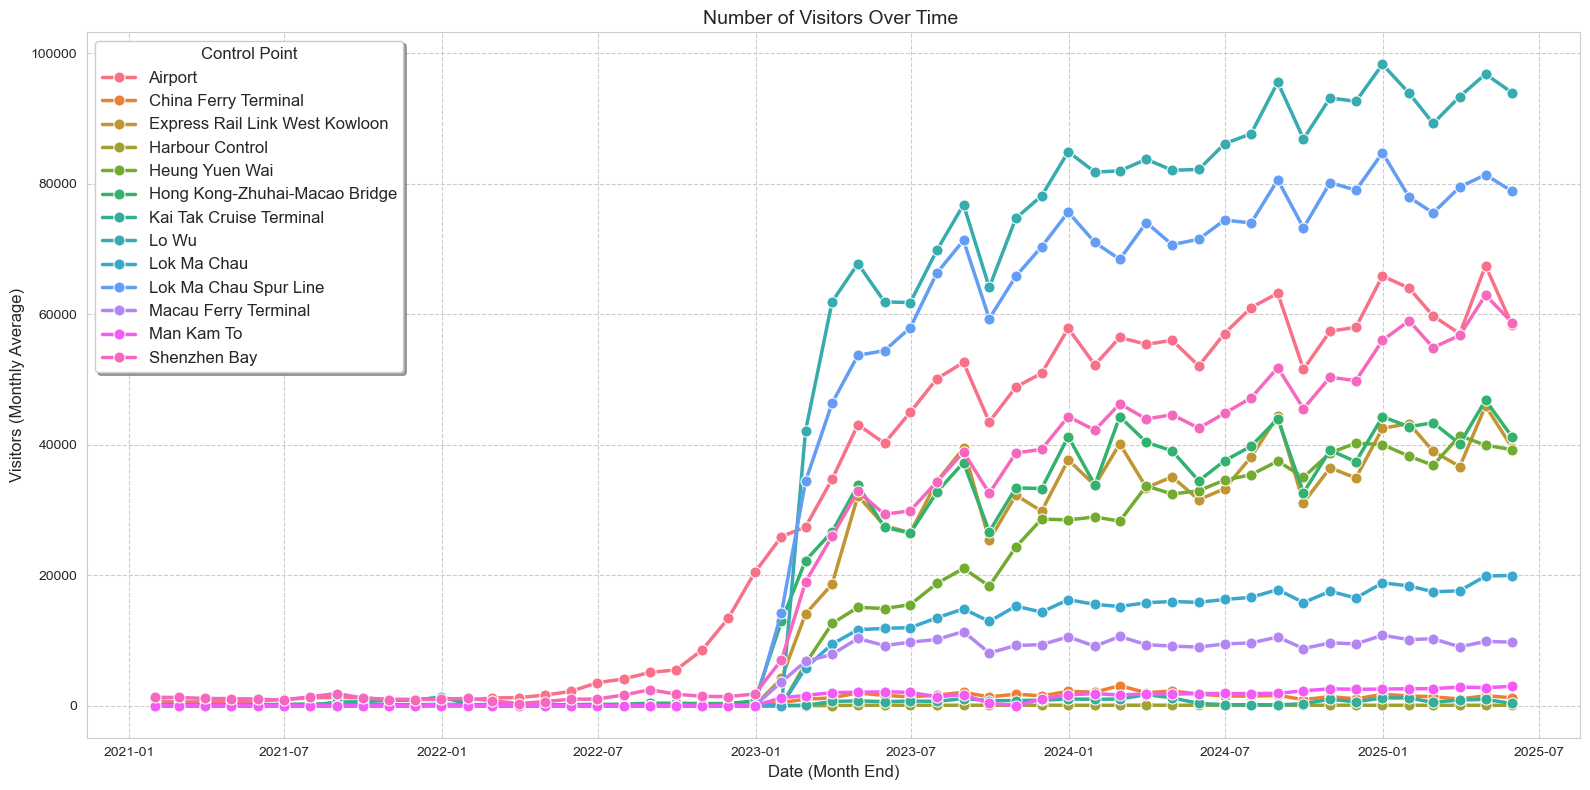

In [19]:
plt.figure(figsize=(16, 8))

sns.lineplot(data=monthly_data_mean, x="Date", y="Total", marker="o", hue = "Control Point", palette="husl", errorbar=None, linewidth=2.5, markersize=8)
    
plt.xlabel("Date (Month End)", fontsize=12)
plt.ylabel("Visitors (Monthly Average)", fontsize=12)
plt.title("Number of Visitors Over Time ", fontsize=14)

legend = plt.legend(fontsize=12, framealpha=1, shadow=True, facecolor="white", bbox_to_anchor=(0, 1), loc="upper left")
legend.set_title("Control Point", prop={"size": 12})

plt.tight_layout()
plt.show();

In [20]:
top_7_control_points = monthly_data_mean.groupby("Control Point").agg({
    "Total" : "sum"}).sort_values("Total", ascending=False).reset_index().head(7)

bot_6_control_points = monthly_data_mean.groupby("Control Point").agg({
    "Total" : "sum"}).sort_values("Total", ascending=True).reset_index().head(6)

top_7_control_points, bot_6_control_points

(                    Control Point      Total
 0                           Lo Wu  4527749.0
 1           Lok Ma Chau Spur Line  3930744.0
 2                         Airport  3182868.0
 3                    Shenzhen Bay  2516712.0
 4   Hong Kong-Zhuhai-Macao Bridge  2080321.0
 5  Express Rail Link West Kowloon  1922325.0
 6                  Heung Yuen Wai  1634907.0,
              Control Point     Total
 0          Harbour Control    2581.0
 1  Kai Tak Cruise Terminal   48910.0
 2     China Ferry Terminal   90045.0
 3               Man Kam To  109824.0
 4     Macau Ferry Terminal  540773.0
 5              Lok Ma Chau  856855.0)

In [21]:
top_7_list = top_7_control_points["Control Point"].values.tolist() 
bot_6_list = bot_6_control_points["Control Point"].values.tolist()

(top_7_list, bot_6_list)

(['Lo Wu',
  'Lok Ma Chau Spur Line',
  'Airport',
  'Shenzhen Bay',
  'Hong Kong-Zhuhai-Macao Bridge',
  'Express Rail Link West Kowloon',
  'Heung Yuen Wai'],
 ['Harbour Control',
  'Kai Tak Cruise Terminal',
  'China Ferry Terminal',
  'Man Kam To',
  'Macau Ferry Terminal',
  'Lok Ma Chau'])

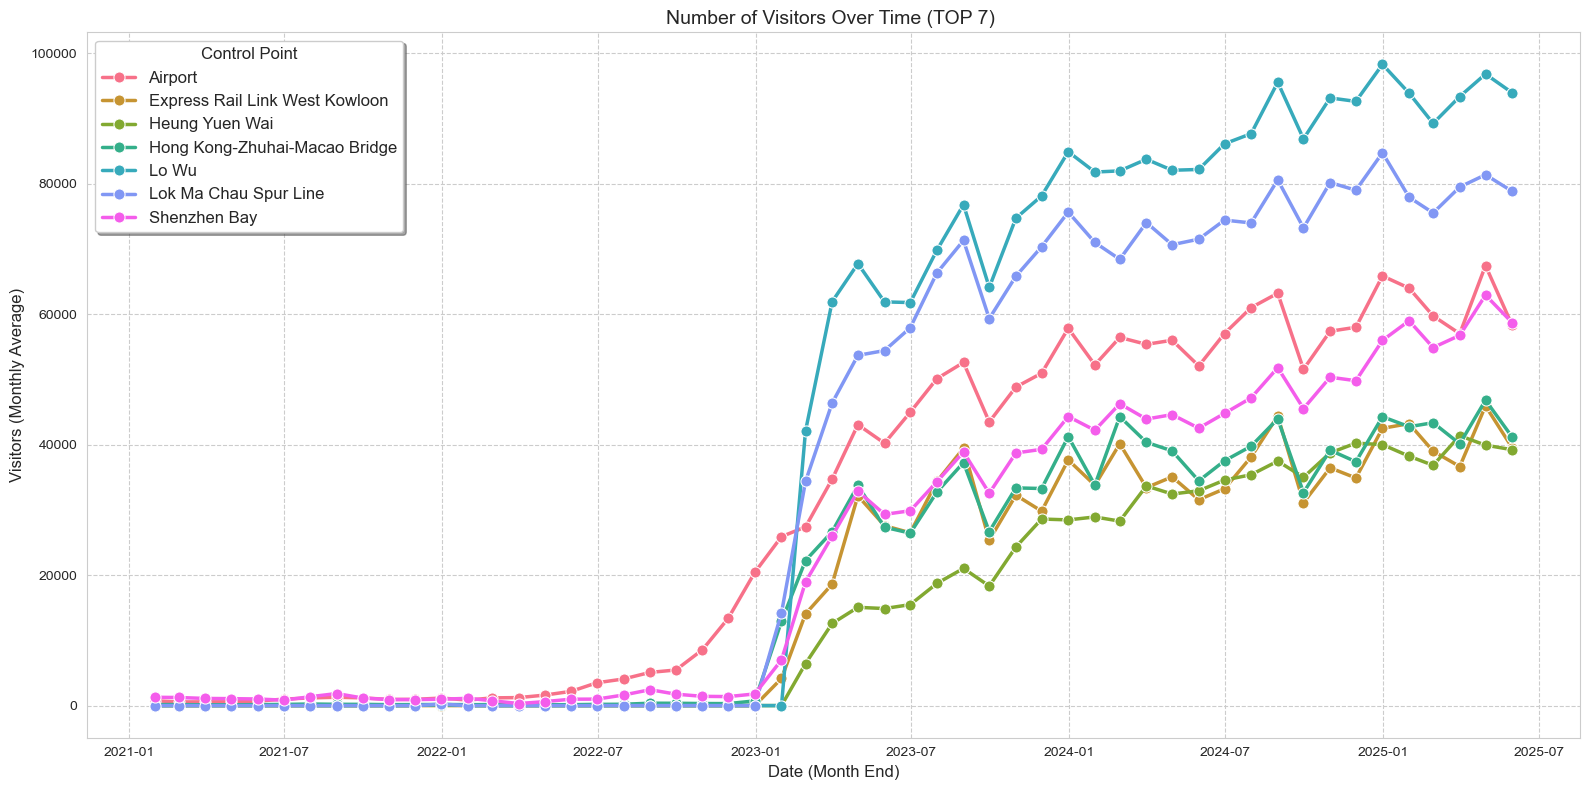

In [22]:
plt.figure(figsize=(16, 8))

sns.lineplot(data=monthly_data_mean[monthly_data_mean["Control Point"].isin(top_7_list)], x="Date", y="Total", marker="o", hue = "Control Point", palette="husl", errorbar=None, linewidth=2.5, markersize=8)
    
plt.xlabel("Date (Month End)", fontsize=12)
plt.ylabel("Visitors (Monthly Average)", fontsize=12)
plt.title("Number of Visitors Over Time (TOP 7) ", fontsize=14)

legend = plt.legend(fontsize=12, framealpha=1, shadow=True, facecolor="white", bbox_to_anchor=(0, 1), loc="upper left")
legend.set_title("Control Point", prop={"size": 12})

plt.tight_layout()
plt.show();

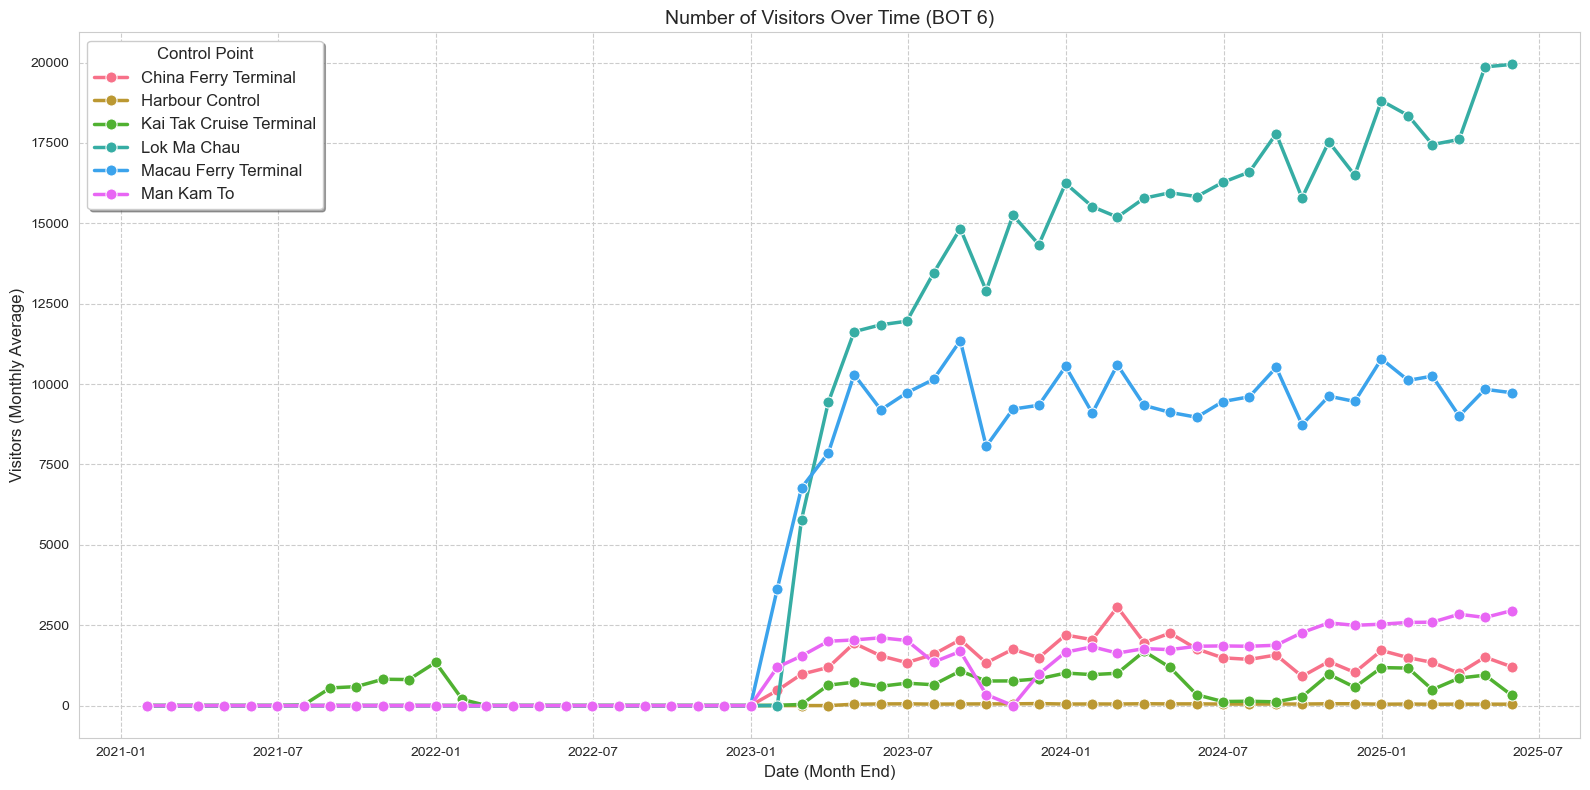

In [23]:
plt.figure(figsize=(16, 8))

sns.lineplot(data=monthly_data_mean[monthly_data_mean["Control Point"].isin(bot_6_list)], x="Date", y="Total", marker="o", hue = "Control Point", palette="husl", errorbar=None, linewidth=2.5, markersize=8)
    
plt.xlabel("Date (Month End)", fontsize=12)
plt.ylabel("Visitors (Monthly Average)", fontsize=12)
plt.title("Number of Visitors Over Time (BOT 6)", fontsize=14)

legend = plt.legend(fontsize=12, framealpha=1, shadow=True, facecolor="white", bbox_to_anchor=(0, 1), loc="upper left")
legend.set_title("Control Point", prop={"size": 12})

plt.tight_layout()
plt.show();

# Data Engineering

After performing some simple exploratory data analysis, we can apply data engineering techniques to uncover more interesting patterns in the data. We will start by extrapolating the day of the week from the date column. Using pandas, we can extract the day of the week from a given date, allowing us to segment our data by weekday. This division will help us analyze trends across different days. We assume that there will be more visitors during weekends compared to weekdays.

In [24]:
grouped_data["Weekday"] = grouped_data["Date"].dt.weekday
grouped_data["Weekday"].value_counts()

Weekday
4    230
5    230
6    230
0    230
1    230
2    229
3    229
Name: count, dtype: int64

In [25]:
grouped_data["Weekday"] = grouped_data["Weekday"].map({0: "Monday", 1: "Tuesday", 2: "Wednesday", 3: "Thursday", 4: "Friday", 5: "Saturday", 6: "Sunday"})
grouped_data["Weekday"]

0         Friday
1       Saturday
2         Sunday
3         Monday
4        Tuesday
          ...   
1603      Friday
1604    Saturday
1605      Sunday
1606      Monday
1607     Tuesday
Name: Weekday, Length: 1608, dtype: object

In [26]:
weekday_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]

grouped_data["Weekday"] = pd.Categorical(grouped_data["Weekday"], categories=weekday_order, ordered=True)

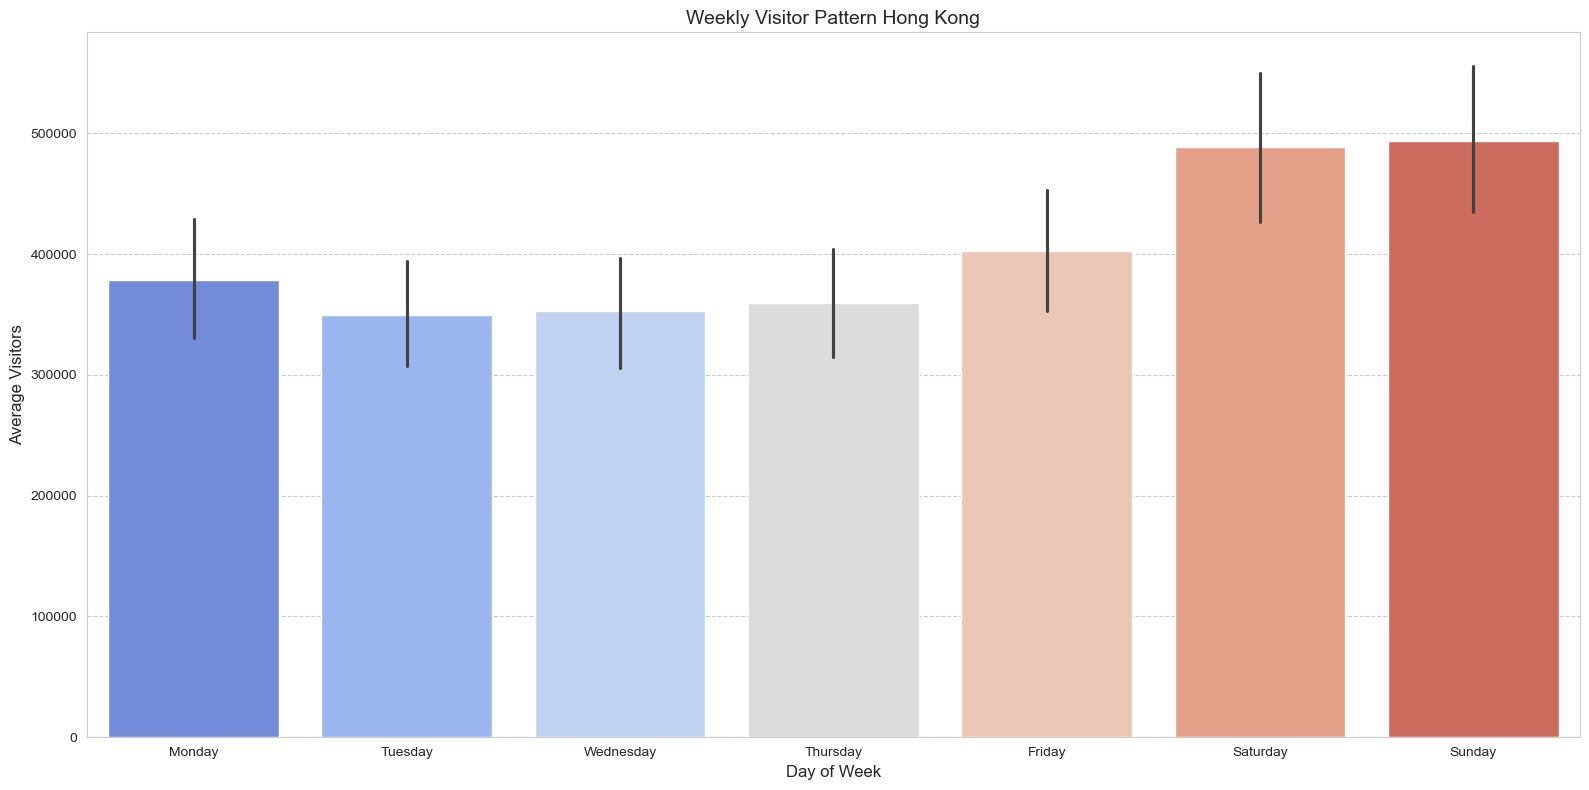

In [27]:
plt.figure(figsize=(16, 8))

sns.barplot(data=grouped_data, x = "Weekday", y = "Total", order = weekday_order, hue = "Weekday", palette = "coolwarm")

plt.xlabel("Day of Week", fontsize=12)
plt.ylabel("Average Visitors", fontsize=12)
plt.title("Weekly Visitor Pattern Hong Kong", fontsize=14)
plt.xticks(rotation=0) 

plt.tight_layout()
plt.show()

The data displays the average number of visitors per day of the week across the entire dataset. As expected, the number of people entering Hong Kong increases during the weekend (Friday, Saturday, and Sunday). Interestingly, Monday also shows a higher average compared to other weekdays. This likely reflects travelers returning from weekend trips to mainland China and abroad, explaining the spike on Monday.

We will now apply a rolling average to reduce the variance introduced by holidays and spikes. This approach provides a clearer understanding of trends compared to a simple monthly average, helping reveal underlying patterns, seasonality, and anomalies.

In [28]:
grouped_data["Total_7day_avg"] = grouped_data["Total"].rolling(7).mean()
grouped_data["Total_30day_avg"] = grouped_data["Total"].rolling(30).mean()

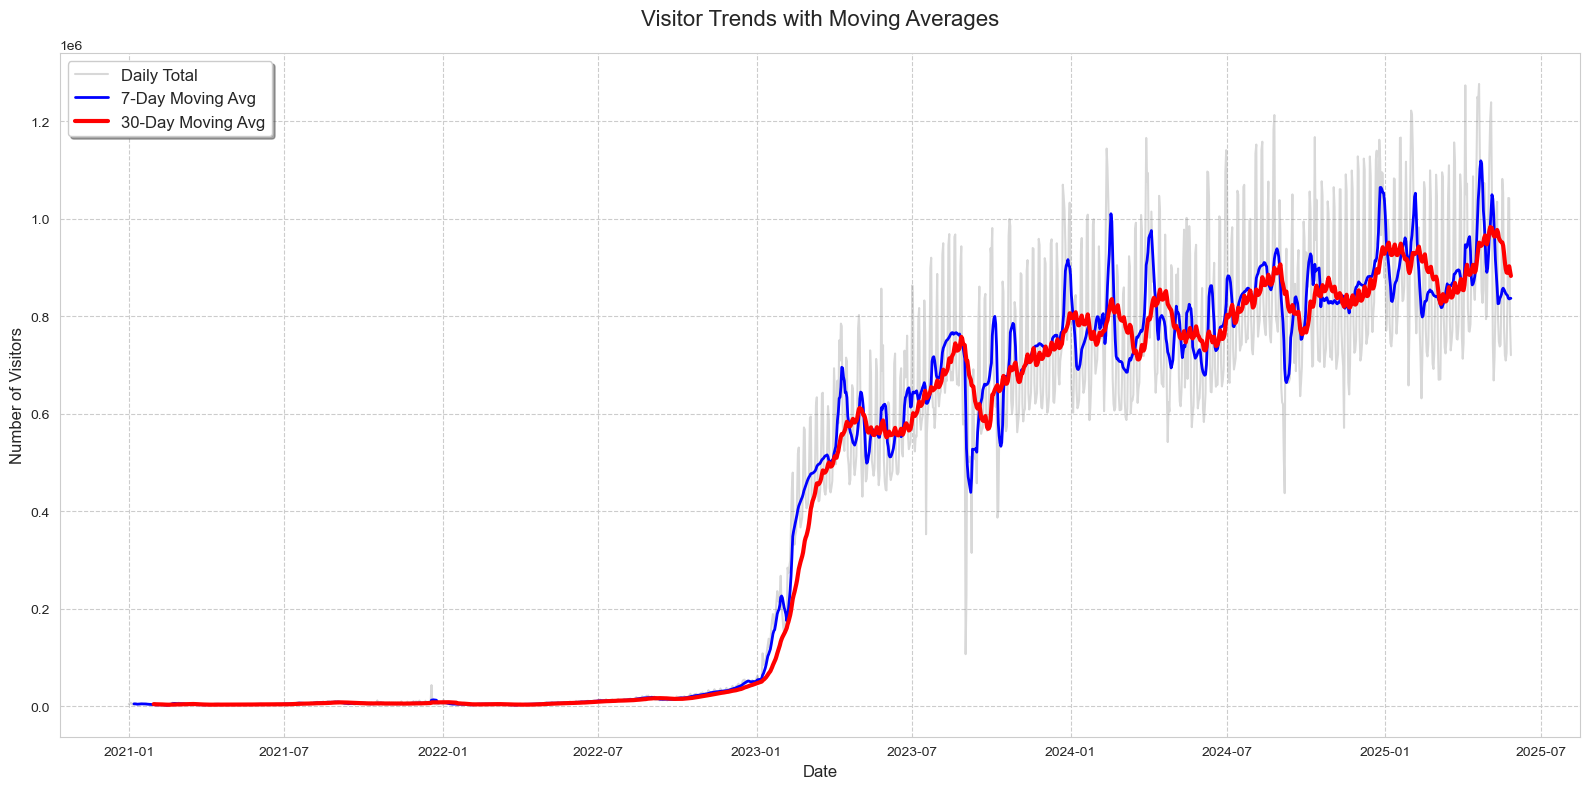

In [29]:
plt.figure(figsize=(16, 8))

plt.plot(grouped_data["Date"], grouped_data["Total"], color="gray", alpha=0.3, label="Daily Total")
plt.plot(grouped_data["Date"], grouped_data["Total_7day_avg"], color="blue", linewidth=2, label="7-Day Moving Avg")
plt.plot(grouped_data["Date"], grouped_data["Total_30day_avg"], color="red", linewidth=3, label="30-Day Moving Avg")

plt.title("Visitor Trends with Moving Averages",  fontsize=16, pad=20)
plt.xlabel("Date", fontsize=12)
plt.ylabel("Number of Visitors", fontsize=12)
plt.legend(fontsize=12, frameon=True, shadow=True)

plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

The graph reveals a significant difference between the 7-day and 30-day moving averages, indicating greater weekly volatility compared to monthly trends. From our earlier analysis, we observe that these fluctuations primarily occur when Hong Kong residents depart and return, likely during peak holiday seasons. The 30-day moving average effectively smooths out these short-term variations, providing a more stable trend representation than the 7-day average. To further enhance our analysis, I will use the Arrival / Departure column, by using it will provide better insights into entry and exit trends in Hong Kong.

In [39]:
entry_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 41808 entries, 0 to 48443
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   Date                 41808 non-null  datetime64[ns]
 1   Control Point        41808 non-null  object        
 2   Arrival / Departure  41808 non-null  object        
 3   Hong Kong Residents  41808 non-null  int64         
 4   Mainland Visitors    41808 non-null  int64         
 5   Other Visitors       41808 non-null  int64         
 6   Total                41808 non-null  int64         
 7   Total_7day_avg       41730 non-null  float64       
 8   Total_30day_avg      41431 non-null  float64       
dtypes: datetime64[ns](1), float64(2), int64(4), object(2)
memory usage: 3.2+ MB


In [40]:
entry_exit_data = entry_data.groupby(["Date", "Arrival / Departure"], as_index=False).agg({
    "Hong Kong Residents": "sum",
    "Mainland Visitors": "sum",
    "Other Visitors": "sum",
    "Total": "sum"
})

entry_exit_data.head()

,Date,Arrival / Departure,Hong Kong Residents,Mainland Visitors,Other Visitors,Total
0,2021-01-01,Arrival,732,45,10,787
1,2021-01-01,Departure,3446,245,32,3723
2,2021-01-02,Arrival,942,78,12,1032
3,2021-01-02,Departure,3903,283,35,4221
4,2021-01-03,Arrival,1770,42,41,1853


In [37]:
entry_data["Total_7day_avg"] = (entry_data.groupby("Control Point")["Total"].rolling(window=7, min_periods=7).mean().reset_index(level=0, drop=True))
entry_data["Total_30day_avg"] = (entry_data.groupby("Control Point")["Total"].rolling(window=30, min_periods=30).mean().reset_index(level=0, drop=True))

/var/folders/yl/rgyyql2n7zq5z298k62k1nt40000gn/T/ipykernel_48955/2408260928.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  entry_data["Total_7day_avg"] = (entry_data.groupby("Control Point")["Total"].rolling(window=7, min_periods=7).mean().reset_index(level=0, drop=True))
/var/folders/yl/rgyyql2n7zq5z298k62k1nt40000gn/T/ipykernel_48955/2408260928.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  entry_data["Total_30day_avg"] = (entry_data.groupby("Control Point")["Total"].rolling(window=30, min_perio

KeyboardInterrupt: 

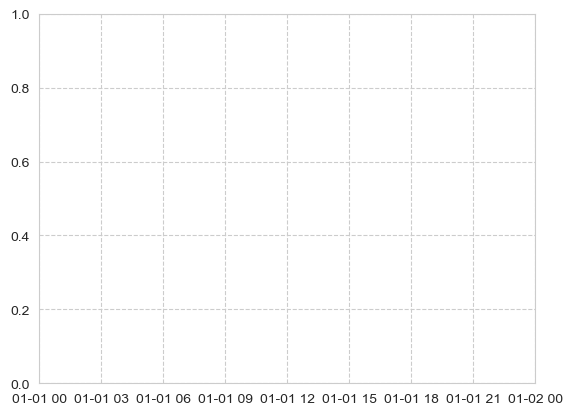

In [38]:
plt.figure(figsize=(16, 8))

data_subset = entry_data[entry_data["Control Point"].isin(top_7_list)]

sns.lineplot(data=data_subset, x="Date", y="Total", color="grey", alpha=0.3)
sns.lineplot(data=data_subset, x="Date", y="Total_7day_avg", color="blue", linewidth=2)
sns.lineplot(data=data_subset, x="Date", y="Total_30day_avg", color="red", linewidth=3)

plt.title("Control Points", fontsize=14)
plt.xlabel("Date (Month End)", fontsize=12)
plt.ylabel("Visitors (Monthly)", fontsize=12)

plt.legend(["Total (grey)", "Total 7-day Avg (blue)", "Total 30-day Avg (red)"], 
           fontsize=12, framealpha=1, shadow=True, facecolor="white")

plt.tight_layout()
plt.show()

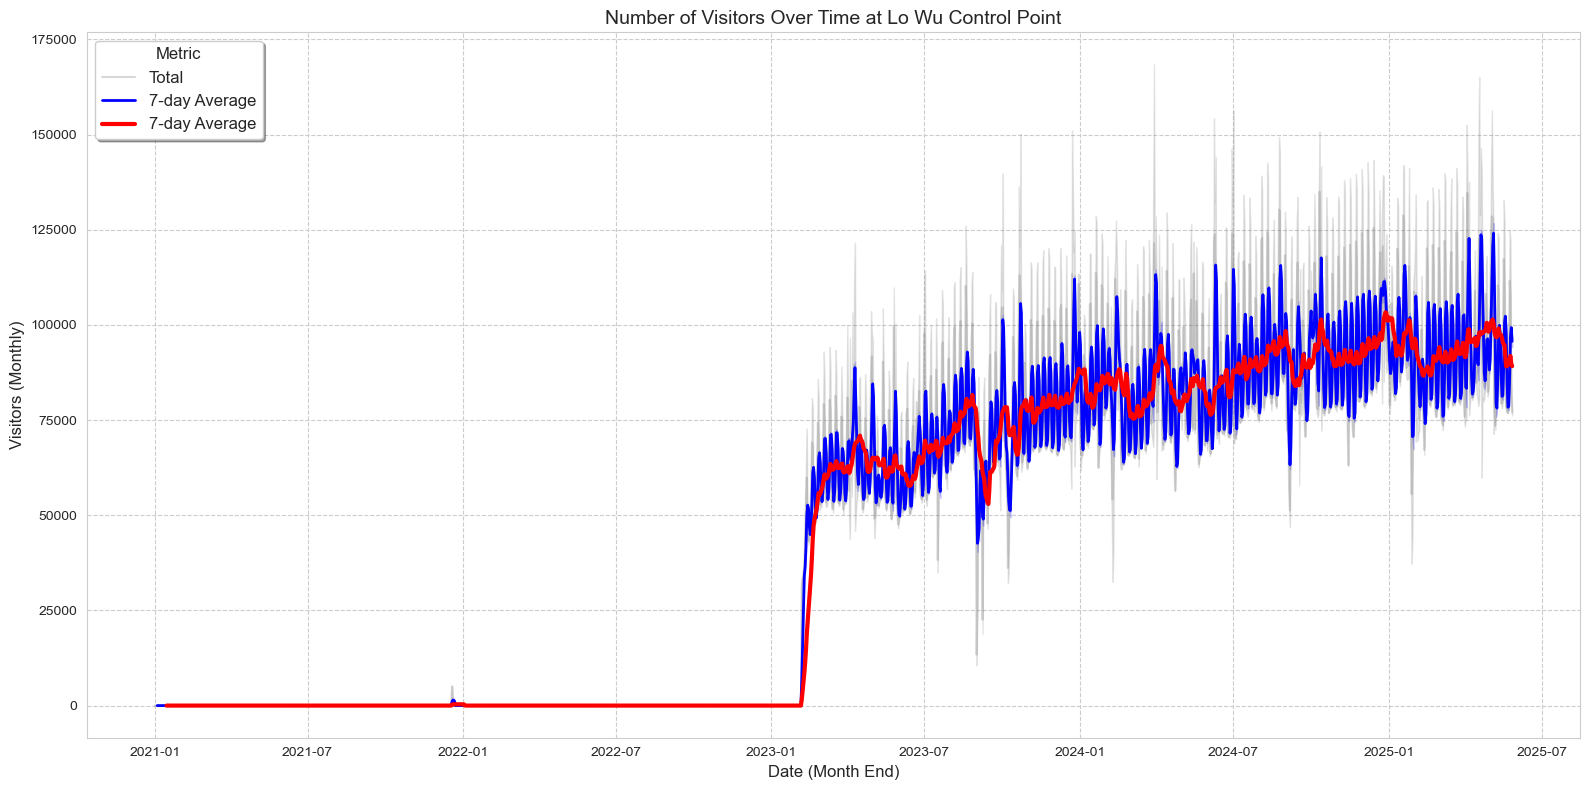

In [37]:
plt.figure(figsize=(16, 8))

sns.lineplot(data=entry_data[entry_data["Control Point"] == "Lo Wu"], x="Date", y="Total", color="grey", label="Daily Total", alpha = 0.3)
sns.lineplot(data=entry_data[entry_data["Control Point"] == "Lo Wu"], x="Date", y="Total_7day_avg", color="blue", linewidth=2, label="7-day Average")
sns.lineplot(data=entry_data[entry_data["Control Point"] == "Lo Wu"], x="Date", y="Total_30day_avg", color="red", linewidth=3, label="30-day Average")
    
plt.xlabel("Date (Month End)", fontsize=12)
plt.ylabel("Visitors (Monthly)", fontsize=12)
plt.title("Number of Visitors Over Time at Lo Wu Control Point", fontsize=14)

legend = plt.legend(fontsize=12, framealpha=1, shadow=True, facecolor="white", bbox_to_anchor=(0, 1), loc="upper left", title="Metric")
legend.get_title().set_fontsize(12)

plt.tight_layout()
plt.show()